In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

In [8]:
import kagglehub

path = kagglehub.dataset_download("kritikseth/fruit-and-vegetable-image-recognition")

print("Path to dataset files:", path)
img_size = (128, 128)
batch_size = 32

Using Colab cache for faster access to the 'fruit-and-vegetable-image-recognition' dataset.
Path to dataset files: /kaggle/input/fruit-and-vegetable-image-recognition


In [11]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = train_datagen.flow_from_directory(
    path, # Changed data_dir to path
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    path, # Changed data_dir to path
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

Found 3061 images belonging to 3 classes.
Found 764 images belonging to 3 classes.


In [12]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [15]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 243s 3s/step - accuracy: 0.8141 - loss: 0.2477 - val_accuracy: 0.8154 - val_loss: 0.0076
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 239s 2s/step - accuracy: 0.8141 - loss: 0.0590 - val_accuracy: 0.8154 - val_loss: 0.0130
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 234s 2s/step - accuracy: 0.8141 - loss: 0.0414 - val_accuracy: 0.8154 - val_loss: 0.0117
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 265s 2s/step - accuracy: 0.8141 - loss: 0.0420 - val_accuracy: 0.8154 - val_loss: 0.0106
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 247s 3s/step - accuracy: 0.8141 - loss: 0.0431 - val_accuracy: 0.8154 - val_loss: 0.0101
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 231s 2s/step - accuracy: 0.8141 - loss: 0.0308 - val_accuracy: 0.8154 - val_loss: 0.0095
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 251s 3s/step - accuracy: 0.8141 - loss: 0.0631 - val_accuracy: 0.8154 - val_loss: 0.0127
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 241s 2s/step - accuracy: 0.8141 - loss: 0.0264 - val_accuracy: 0.8154 - v

In [16]:
loss, accuracy = model.evaluate(val_data)
print("Validation Accuracy:", accuracy)

24/24 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.8154 - loss: 0.0131
Validation Accuracy: 0.8154450058937073


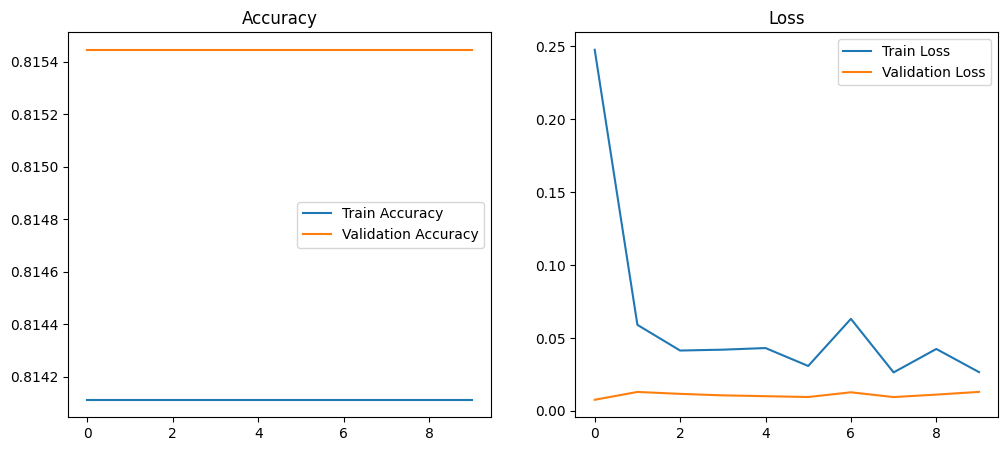

In [17]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")

plt.show()

In [21]:
from tensorflow.keras.preprocessing import image
import os

test_dir = os.path.join(path, 'test')

categories = os.listdir(test_dir)

if categories:
    sample_category_path = os.path.join(test_dir, categories[0])

    if os.listdir(sample_category_path):
        img_filename = os.listdir(sample_category_path)[0]
        img_path = os.path.join(sample_category_path, img_filename)
    else:
        print(f"No images found in category: {categories[0]}")
        img_path = "/content/test.jpg"
else:
    print("No categories found in the test directory.")
    img_path = "/content/test.jpg"
print(f"Using image for prediction: {img_path}")

img = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Vegetable")
else:
    print("Fruit")

Using image for prediction: /kaggle/input/fruit-and-vegetable-image-recognition/test/capsicum/Image_4.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Vegetable
